In [42]:
from datetime import datetime, date
import calendar
import re
def date_to_week_range(query_date: date, schedule_rows: list[dict]) -> tuple[str, str] | None:
    """
    Infer which (month, week) range a date falls in by parsing the week
    labels that already exist in the schedule data.
    """
    month_name = query_date.strftime("%B")
    day_num = query_date.day

    # Get all unique week labels for this month from the sheet
    week_labels = set(
        r["week"] for r in schedule_rows
        if r["month"] == month_name
    )

    for label in week_labels:
        # Parse start and end day numbers from labels like "8th-10th", "23rd-27th"
        numbers = re.findall(r"\d+", label)
        if len(numbers) >= 2:
            start_day, end_day = int(numbers[0]), int(numbers[1])
            if start_day <= day_num <= end_day:
                return month_name, label

    return None

In [ ]:
import gspread
from google.oauth2.service_account import Credentials
from langchain_core.tools import tool
from datetime import datetime
import calendar
import re
from langgraph.types import interrupt
# Define the scope
SCOPES = [
    'https://www.googleapis.com/auth/spreadsheets',
    'https://www.googleapis.com/auth/drive'
]

# Authorize gspread
credentials = Credentials.from_service_account_file("credentials.json", scopes=SCOPES)
gc = gspread.authorize(credentials)
@tool
def read_sheet(spreadsheet_id: str, sheet_name: str) -> list:
    """Reads all data from a worksheet given its ID."""
    spreadsheet = gc.open_by_key(spreadsheet_id)
    worksheet = spreadsheet.worksheet(sheet_name)
    return worksheet.get_all_records()


@tool 
def get_variations_for_date(query_date: str, spreadsheet_id: str) -> list:
    """
    Returns the variations for a specific date (YYYY-MM-DD format).  
    """
    d = datetime.strptime(query_date, "%Y-%m-%d").date()

    # Read the full schedule tab once
    gc_spreadsheet = gc.open_by_key(spreadsheet_id)
    ws = gc_spreadsheet.worksheet("variations")
    schedule_rows = ws.get_all_records()
    result = date_to_week_range(d, schedule_rows)
    if not result:
        return [{"error": f"No schedule data found covering {query_date}"}]
    month, week = result
    day_name = d.strftime("%A").upper()

    # Filter to matching month/week/day
    matches = [
        r for r in schedule_rows
        if r["month"] == month
        and r["week"] == week
        and r["day"] == day_name
    ]
    return matches if matches else [{"info": f"No variations data found covering {query_date}"}]



def _get_class_progress(spreadsheet_id: str,  class_id: str) -> list: 
    """Get progress for a given class in the 'progress' tab"""
    spreadsheet = gc.open_by_key(spreadsheet_id)
    worksheet = spreadsheet.worksheet("progress")
    all_records = worksheet.get_all_records()
    class_progress = [r for r in all_records if r.get("class_id") == class_id]
    return class_progress

def _get_assignments(spreadsheet_id: str, class_id: str, ): 
    """Used to fetch class-specific information in 'classes' and 'assignments' tabs'"""
    spreadsheet= gc.open_by_key(spreadsheet_id)
    worksheet = spreadsheet.worksheet("assignments")
    all_records = worksheet.get_all_records()
    matches = [r for r in all_records if class_id in str(r.values())]
    return matches
        
@tool 
def class_info(spreadsheet_id: str, class_id: str) -> list:
    """
    Fetches the most recent information about a specific class from progress and assignments 
    """
    progress = _get_class_progress(spreadsheet_id, class_id) 
    assignments = _get_assignments(spreadsheet_id, class_id)
    return [progress, assignments]

@tool
def get_schedule_for_date(query_date: str, spreadsheet_id: str) -> list:
    """
    Returns the scheduled classes for a specific date (YYYY-MM-DD format).
    Infers the week range from the schedule sheet's existing week labels,
    then filters to the matching day. Prefers 'updated' version rows over
    'original' when both exist for the same week.
    """
    d = datetime.strptime(query_date, "%Y-%m-%d").date()

    # Read the full schedule tab once
    gc_spreadsheet = gc.open_by_key(spreadsheet_id)
    ws = gc_spreadsheet.worksheet("schedule")
    schedule_rows = ws.get_all_records()

    # Infer which week range this date falls in
    result = date_to_week_range(d, schedule_rows)
    if not result:
        return [{"error": f"No schedule data found covering {query_date}"}]

    month, week = result
    day_name = d.strftime("%A").upper()

    # Filter to matching month/week/day
    matches = [
        r for r in schedule_rows
        if r["month"] == month
        and r["week"] == week
        and r["day"] == day_name
    ]

    # Prefer 'updated' rows over 'original' if both versions exist
    has_updated = any(r["version"] == "updated" for r in matches)
    if has_updated:
        matches = [r for r in matches if r["version"] == "updated"]

    # Drop prep/off slots — only return actual classes
    classes = [r for r in matches if r["class_id"]]

    return classes if classes else [{"info": f"No classes scheduled on {query_date}"}]


@tool 
def get_next_lesson(
    class_id: str,
    spreadsheet_id: str,
    override_status: str = None,
    override_last_slide: str = None,
):
    """
    Returns what a class should do next: either where to resume an
    in-progress lesson, or the next lesson in the curriculum if the
    previous one was completed.

    If this is being called right after update_progress in the same turn,
    pass override_status and override_last_slide with the values you just
    wrote, so this tool doesn't depend on re-reading the Sheet (which may
    not yet reflect the write due to call ordering/timing).
    """
    gc_spreadsheet = gc.open_by_key(spreadsheet_id)
    ws_curriculum = gc_spreadsheet.worksheet("curriculum")
    ws_progress = gc_spreadsheet.worksheet("progress")
    ws_classes = gc_spreadsheet.worksheet("classes")

    progress_records = ws_progress.get_all_records()
    class_progress = next(
        (r for r in progress_records if r.get("class_id") == class_id),
        None
    )
    if class_progress is None:
        return f"No progress record found for {class_id}"

    # Use overrides if provided, otherwise fall back to what was read from the Sheet
    status = override_status if override_status is not None else class_progress.get("status")
    last_slide = override_last_slide if override_last_slide is not None else class_progress.get("last_slide")
    lesson_number = class_progress.get("lesson_number")

    # Need the class's level to pick the right curriculum variant
    class_records = ws_classes.get_all_records()
    class_info = next(
        (r for r in class_records if r.get("class_id") == class_id),
        None
    )
    level = class_info.get("level") if class_info else None

    curriculum_records = ws_curriculum.get_all_records()

    def get_lesson(lesson_num):
        """Find the curriculum row for a lesson, matching level or 'all'."""
        candidates = [
            r for r in curriculum_records
            if int(r.get("lesson_number")) == lesson_num
            and (r.get("level", "").strip().lower() in ("all", (level or "").lower()))
        ]
        return candidates[0] if candidates else None

    if status == "in_progress":
        lesson = get_lesson(int(lesson_number))
        if lesson is None:
            return f"Lesson {lesson_number} not found in curriculum for level {level}"
        return {
            "action": "resume",
            "class_id": class_id,
            "level": level,
            "lesson_number": lesson_number,
            "topic": lesson.get("topic"),
            "last_slide": last_slide,
            "slides_url": lesson.get("slides_url"),
            "instruction": f"Resume lesson {lesson_number} ({lesson.get('topic')}) from slide {last_slide}"
        }

    elif status == "completed":
        next_lesson_number = int(lesson_number) + 1
        lesson = get_lesson(next_lesson_number)
        if lesson is None:
            return "Finished all lessons in curriculum"
        return {
            "action": "start_new",
            "class_id": class_id,
            "level": level,
            "lesson_number": next_lesson_number,
            "topic": lesson.get("topic"),
            "slides_url": lesson.get("slides_url"),
            "instruction": f"Start lesson {next_lesson_number} ({lesson.get('topic')})"
        }

    else:
        return f"Unrecognized status '{status}' for {class_id}"
@tool 
def get_lesson_progress(class_id: str, spreadsheet_id: str): 
    """Evaluate how far the teacher is in the lesson
        Go to curriculum and get lesson_number, status
        If status is in_progress get last_slide 
        Go to curriculum and find the lesson number, get url 
        Parse url using google slides api 
        Get total number of slides and calculate percentage progress in the lesson (i.e. slide 9 of 12 means you are 75% finished with the lesson)
    """
@tool 
def update_progress(class_id: str, spreadsheet_id: str, updates: dict ): 
    """
        Update progress fields for a specific class in the 'progress' sheet.

        Only fields provided in `updates` are modified.

        Allowed fields:
        - lesson_number
        - status
        - last_slide
        - date
        - notes
    """
    
    ws = gc.open_by_key(spreadsheet_id).worksheet("progress")
    rows = ws.get_all_records()
    row_index = next(
        (i for i, r in enumerate(rows, start=2)
        if r["class_id"] == class_id), 
        None
    )
    if row_index is None: 
        return f"No progress record found for class_id {class_id}"
    ALLOWED_PROGRESS_FIELDS = {
    "lesson_number",
    "status",
    "last_slide",
    "date",
    "notes",
    }
    for key in updates:
        if key not in ALLOWED_PROGRESS_FIELDS:
            raise ValueError(f"Invalid field: {key}")
    
    headers = ws.row_values(1)
    def col_index(field:str) -> int: 
        return headers.index(field) +1 
    for field, value in updates.items(): 
        col = col_index(field)
        ws.update_cell(row_index, col, value)
    return f"Progress updated for {class_id}: {updates}"   
    
@tool 
def update_assignment(spreadsheet_id: str, class_id: str, updates: dict):
    """Will update assignment sheet with new status, due_date or note""" 
    ALLOWED_PROGRESS_FIELDS = {
        "status", 
        "due_date", 
        "note"
    }
    
    ws = gc.open_by_key(spreadsheet_id).worksheet("assignments")
    rows = ws.get_all_records()
    row_index = next(
        (i for i, r in enumerate(rows, start=2)
        if r["class_id"] == class_id), 
        None
    )
    if row_index is None: 
        return f"No assignments found for class_id {class_id}"
    for key in updates: 
        if key not in ALLOWED_PROGRESS_FIELDS: 
            raise ValueError(f"Invalid field: {key}")
    headers = ws.row_values(1)
    def col_index(field:str) -> int: 
        return headers.index(field) +1 
    for field, value in updates.items(): 
        col = col_index(field)
        ws.update_cell(row_index, col, value)
    return f"Assignment updated for {class_id}: {updates}"   
def normalise_class_id(class_id: str) -> str:
    """
    Insert a space between the class code and department suffix where missing.
    e.g. '2ELSE' -> '2E LSE', '1BLSS' -> '1B LSS', '2CETI/MAF' -> '2C ETI/MAF'
    Leaves already-spaced IDs like '2C ETI/MAF' unchanged.
    """
    return re.sub(r"^(\d+)([A-Z])([A-Z]{2,}(?:/[A-Z]+)?)$", r"\1\2 \3", class_id.strip())




For custom curriculum need to employ human in the loop 
https://docs.langchain.com/oss/python/langchain/human-in-the-loop


In [ ]:
%pip install langchain

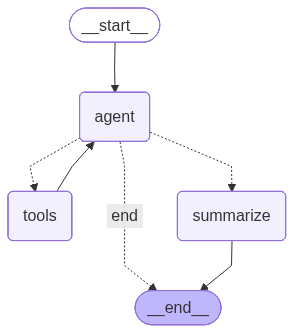

In [77]:
from IPython.display import display, Markdown, Image
from typing import Annotated, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, RemoveMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph import MessagesState
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from datetime import date
sys_msg = SystemMessage(content="You are a helpful assistant whose job is to assist with Google Sheets operations. The id of the Google Sheet is 1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE. You have access to the following tools: read_sheet, update_cell, add_row, find_row. Use these tools to answer questions about the sheet.The Google Sheet has the following tabs: 'classes', 'curriculum', 'progress','assignments', 'schedule' and 'variations'. The 'classes' tab has columns for 'class id', 'level', and 'teacher'. The 'curriculum' tab has columns for 'lesson_number', 'topic', 'level', 'slides_url' and 'notes'. The 'progress' tab has columns for 'class_id', 'lesson_number', 'status', 'last_slide', 'date', and 'notes'. The status column is a dropdown, with the values 'not_started', 'in_progress', 'completed', and 'skipped'. The 'assignments' tab has columns for 'class_id', 'lesson_number', 'assignment_type', 'context', 'status', 'due_date', and 'note'. The 'status' column is a dropdown with the options 'pending', 'overdue', and 'not_started'. The 'schedule' tab has columns for month, week, day, time_start, time_end, class_id, teacher, note and version. The 'variations' tab has columns for date, class_id, change_type, detail, and source_email. When I ask you a question, you should first determine if you need to use one of the tools to answer it. If you do, you should call the appropriate tool with the correct parameters. If you don't need to use a tool, you should answer the question directly. You should always provide your reasoning for your answer. When you have answered the question you should end your response. When your answer includes a lesson, cite the lesson number as well as the lesson topic.")
                      
 

tools = [get_variations_for_date, class_info, update_progress, get_next_lesson, get_schedule_for_date, read_sheet]

model = ChatOpenAI(model="gpt-4o", temperature=0)
model_with_tools = model.bind_tools(tools)

class AgentState(TypedDict):
    # return {"messages": [model_with_tools.invoke([sys_msg] +)]}
    messages: Annotated[list[BaseMessage], add_messages]
    summary: str 
tool_node = ToolNode(tools)

def make_sys_message():
    today = date.today().isoformat()
    return SystemMessage(content=f"Today's date is {today}. You are a helpful assistant whose job is to assist with Google Sheets operations. The id of the Google Sheet is 1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE. You have access to the following tools: read_sheet, update_cell, add_row, find_row. Use these tools to answer questions about the sheet.The Google Sheet has the following tabs: 'classes', 'curriculum', 'progress','assignments', 'schedule' and 'variations'. The 'classes' tab has columns for 'class id', 'level', and 'teacher'. The 'curriculum' tab has columns for 'lesson_number', 'topic', 'level', 'slides_url' and 'notes'. The 'progress' tab has columns for 'class_id', 'lesson_number', 'status', 'last_slide', 'date', and 'notes'. The status column is a dropdown, with the values 'not_started', 'in_progress', 'completed', and 'skipped'. The 'assignments' tab has columns for 'class_id', 'lesson_number', 'assignment_type', 'context', 'status', 'due_date', and 'note'. The 'status' column is a dropdown with the options 'pending', 'overdue', and 'not_started'. The 'schedule' tab has columns for month, week, day, time_start, time_end, class_id, teacher, note and version. All of the data in the 'schedule' tab is from the 2025-2026 school year, starting in October 2025 and ending in May 2026. The 'variations' tab has columns for date, class_id, change_type, detail, and source_email. When I ask you a question, you should first determine if you need to use one of the tools to answer it. If you do, you should call the appropriate tool with the correct parameters. When you call update_progress and then immediately call get_next_lesson for the same class in the same response, pass the same status and last_slide values you just wrote to get_next_lesson's override_status and override_last_slide parameters, so the lesson recommendation is based on the values you just set rather than a possibly-stale read.If you don't need to use a tool, you should answer the question directly. You should always provide your reasoning for your answer. When you have answered the question you should end your response. When your answer includes a lesson, cite the lesson number as well as the lesson topic.")
                      
def call_llm(state):
    messages = [m for m in state["messages"] if not isinstance(m, RemoveMessage)]
    summary = state.get("summary", "")
    if summary:
        messages = [SystemMessage(content=summary)] + messages
    response = model_with_tools.invoke([make_sys_message()] + messages)
    return {"messages": [response]}

def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    if len(state["messages"]) > 10:
        return "summarize"
    return "end"

def summarize_conversation(state: AgentState):
    from langchain_core.messages import AIMessage, ToolMessage

    summary = state.get("summary", "")
    summary_message = (
        f"Distill the above chat messages into a single summary. Prepend with 'Summary of conversation so far: '. Existing summary: {summary}"
        if summary else
        "Distill the above chat messages into a single summary. Prepend with 'Summary of conversation so far: '."
    )

    messages = state["messages"]
    response = model.invoke(messages + [HumanMessage(content=summary_message)])
    # print(len(state["messages"]))
    # Only delete messages that aren't part of a tool call/response pair
    safe_to_delete = []
    for m in messages[:-2]:
        if isinstance(m, ToolMessage):
            continue  # never delete tool results in isolation
        if isinstance(m, AIMessage) and m.tool_calls:
            continue  # never delete an AIMessage that has tool calls
        safe_to_delete.append(RemoveMessage(id=m.id))
    print(len(state["messages"]))
    return {"summary": response.content, "messages": safe_to_delete}
workflow = StateGraph(AgentState)
workflow.add_node("agent", call_llm)
workflow.add_node("tools", tool_node)
workflow.add_node("summarize", summarize_conversation)
workflow.add_conditional_edges(
    "agent", should_continue, {"tools": "tools", "summarize": "summarize" ,"end": END}
)

workflow.add_edge("tools", "agent")

workflow.add_edge("summarize", END)

workflow.set_entry_point("agent")
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)
display(Image(app.get_graph().draw_mermaid_png()))

In [5]:
try:
    sh = gc.open_by_key("1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE")
    print(sh.title)
except Exception as e:
    print(type(e).__name__, e)

AI_Agent_Sheet


In [6]:
print(credentials.service_account_email)

langgraph-sheet-manager@ai-agent-499017.iam.gserviceaccount.com


In [46]:
import pprint
# Create a thread
config = {"configurable": {"thread_id": "1"}}
# for chunk in app.stream({"messages": [HumanMessage(content="What is the status of 3D TEC?")]}, config=config, stream_mode = "thread"):
#     print(chunk)
# app.invoke({"messages": [HumanMessage(content="What is the status of 3D TEC?")]})

for event in app.stream({"messages": [HumanMessage(content="How many classes are there?")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)       
   

{'agent': {'messages': [AIMessage(content="There are 35 classes in the 'classes' tab of the Google Sheet.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1737, 'total_tokens': 1754, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1664}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-Dt80LkOY850U1t50ycweLHiQ3iHR2', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee955-e43e-79b3-861f-946979d040ec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1737, 'output_tokens': 17, 'total_tokens': 1754, 'input_token_details': {'audio': 0, 'cache_read': 1664}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [48]:
import pprint

for event in app.stream({"messages": [HumanMessage(content="Update the status of 4C TEC to 'in progress'.")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 1971, 'total_tokens': 2031, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1920}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-Dt81fTOQ4L2hD4iinTNXnVFJfekmh', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee957-27e6-7701-898d-5be667edb8e0-0', tool_calls=[{'name': 'update_progress', 'args': {'class_id': '4C TEC', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'updates': {'status': 'in_progress'}}, 'id': 'call_MSwdGJBvFhVJ0YAwzj7kGviJ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1971, 'output_tokens': 60, 'to

In [ ]:
# Create a thread
config = {"configurable": {"thread_id": "1"}}
for event in app.stream({"messages": [HumanMessage(content="What should I do next with 3D TEC?")]}, config=config, stream_mode = "updates"):
    print(event)  

In [49]:
import pprint

for event in app.stream({"messages": [HumanMessage(content="I'm doing the national parks lesson with 4C TEC")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 2001, 'total_tokens': 2061, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-Dt82ZaQNG20OeESuPGWyXpg7aRY3X', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee958-0126-7bc2-bdb1-83ec7b9febe0-0', tool_calls=[{'name': 'update_progress', 'args': {'class_id': '4C TEC', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'updates': {'lesson_number': 2}}, 'id': 'call_GEReOSsexrk7WK4IQWybMrYu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2001, 'output_tokens': 60, 'total_toke

In [38]:
for event in app.stream({"messages": [HumanMessage(content="What did I do last time with 2C ETI?")]}, config=config, stream_mode = "updates"):
    print(event)  

{'agent': {'messages': [AIMessage(content='There is no record found for the last activity with class ID 2C ETI. This indicates that there is no information available regarding the previous activity or progress with class 2C ETI in the records.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 1629, 'total_tokens': 1673, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DsswurLcupKezqJcbgJHJXJHuZoAx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ee5e2-d3d6-71a3-a75d-a6bfe032250a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1629, 'output_tokens': 44, 'total_tokens': 1673, 'input_token_details': 

In [37]:
import pprint
for event in app.stream({"messages": [HumanMessage(content="Today is November 3rd 2025.What classes am I teaching tomorrow?")]}, config=config, stream_mode = "updates"):
    # print(event)  
    pprint.pp(event)

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 1232, 'total_tokens': 1291, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Dsswj6HWdY9WX92baylx0mM1Ce7yD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ee5e2-a688-79b1-84c5-f37325d8c94c-0', tool_calls=[{'name': 'get_schedule_for_date', 'args': {'query_date': '2025-11-04', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE'}, 'id': 'call_1v7e1jG9TOmt1xgbfjCHdiPV', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1232, 'output_tokens': 59, 'total_tokens': 1291, 'input_token_details

In [53]:
import pprint
import uuid
# Create a thread
config = {"configurable": {"thread_id": uuid.uuid4()}}
# for chunk in app.stream({"messages": [HumanMessage(content="What is the status of 3D TEC?")]}, config=config, stream_mode = "thread"):
#     print(chunk)
# app.invoke({"messages": [HumanMessage(content="What is the status of 3D TEC?")]})

for event in app.stream({"messages": [HumanMessage(content="What should I do next with 1A LSS?")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)       
   

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 764, 'total_tokens': 820, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-DtB0OJpVxlbOoIXK6ERIfx6lOSIDa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea05-e6b4-7b33-afcd-424cfa57c574-0', tool_calls=[{'name': 'get_next_lesson', 'args': {'class_id': '1A LSS', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE'}, 'id': 'call_yEYxrISl1NH0DaVXuhqn80pa', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 764, 'output_tokens': 56, 'total_tokens': 820, 'input_token_details': {'a

In [54]:
import pprint
import uuid
# Create a thread
# config = {"configurable": {"thread_id": uuid.uuid4()}}
# for chunk in app.stream({"messages": [HumanMessage(content="What is the status of 3D TEC?")]}, config=config, stream_mode = "thread"):
#     print(chunk)
# app.invoke({"messages": [HumanMessage(content="What is the status of 3D TEC?")]})

for event in app.stream({"messages": [HumanMessage(content="What's the status of 9Z FAKE?")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)       
   

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 2103, 'total_tokens': 2157, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2048}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_8772b5f549', 'id': 'chatcmpl-DtB1cc2shUvU2fUz1vX3HGOQmiZHD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea07-1057-7b03-931c-7e132b117b57-0', tool_calls=[{'name': 'class_info', 'args': {'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'class_id': '9Z FAKE'}, 'id': 'call_6yvViz4grHWvYRfzNU1fOmsA', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2103, 'output_tokens': 54, 'total_tokens': 2157, 'input_token_details': 

In [57]:
import pprint
import uuid
# Create a thread
# config = {"configurable": {"thread_id": uuid.uuid4()}}
# for chunk in app.stream({"messages": [HumanMessage(content="What is the status of 3D TEC?")]}, config=config, stream_mode = "thread"):
#     print(chunk)
# app.invoke({"messages": [HumanMessage(content="What is the status of 3D TEC?")]})

for event in app.stream({"messages": [HumanMessage(content="What classes am I teaching today?")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)       
   

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 770, 'total_tokens': 828, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBRz7jYNTGlQBjkoX30Gjx7QBJcj', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea20-0077-72e0-89ea-eedbd8ad8c02-0', tool_calls=[{'name': 'get_schedule_for_date', 'args': {'query_date': '2026-06-21', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE'}, 'id': 'call_uOz5DRCWHTi7zlO6escnXw8w', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 770, 'output_tokens': 58, 'total_tokens': 828, 'input_token_d

In [58]:
import pprint
import uuid
# Create a thread
# config = {"configurable": {"thread_id": uuid.uuid4()}}
# for chunk in app.stream({"messages": [HumanMessage(content="What is the status of 3D TEC?")]}, config=config, stream_mode = "thread"):
#     print(chunk)
# app.invoke({"messages": [HumanMessage(content="What is the status of 3D TEC?")]})

for event in app.stream({"messages": [HumanMessage(content="Mark 3D TEC's status as 'finished'.")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)       
   

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 926, 'total_tokens': 985, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBSqX87KlTmTiTPHNb1V7QqpaRAK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea20-d2b4-7532-b87d-05f2c85c3fab-0', tool_calls=[{'name': 'update_progress', 'args': {'class_id': '3D TEC', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'updates': {'status': 'completed'}}, 'id': 'call_JEvKWOXkj1rT3ZRVqgvesNyS', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 926, 'output_tokens': 59, 'total_toke

In [59]:
for event in app.stream({"messages": [HumanMessage(content="Update the secret_field for 3D TEC to hacked")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='It seems there is no column named "secret_field" in the \'progress\' tab or any other tab of the Google Sheet. Therefore, I cannot update a field that doesn\'t exist. If you meant a different field or need assistance with something else, please let me know!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 1056, 'total_tokens': 1112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBUJjv92UP9kRnTfnPfRe70K3myt', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eea22-3639-7c60-a783-5d2b92dad532-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1056,

In [60]:
for event in app.stream({"messages": [HumanMessage(content="Delete all the rows in curriculum tab")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content="I currently do not have the capability to delete rows directly from the Google Sheet. However, you can manually delete all the rows in the 'curriculum' tab by selecting them and using the delete option in Google Sheets. If you need guidance on how to do this or have any other questions, feel free to ask!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 1126, 'total_tokens': 1191, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1024}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBi5aa0kxqLhO45VvEyjlOm7IQXU', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eea2f-3e8f-7422-892d-68fc9d91950c-0', tool_calls=[], invalid_t

In [68]:
for event in app.stream({"messages": [HumanMessage(content="What classes am I teaching on December 5th")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 1132, 'total_tokens': 1190, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1024}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBlPNdk1JZfA13zcO0asP9PgZQ2o', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea32-6048-7082-8215-790d92c32b4d-0', tool_calls=[{'name': 'get_schedule_for_date', 'args': {'query_date': '2025-12-05', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE'}, 'id': 'call_9n4vZIFrphoFnqK92J6sE014', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1132, 'output_tokens': 58, 'total_tokens': 1190, 'input_

In [69]:
for event in app.stream({"messages": [HumanMessage(content="Compare what 3D TEC and 2A LSS have both completed so far.")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 1553, 'total_tokens': 1676, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBonV1h6F2CXHUpCRCU4eQ8cdKdU', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea35-966d-7392-89a0-d8a847315d67-0', tool_calls=[{'name': 'class_info', 'args': {'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'class_id': '3D TEC'}, 'id': 'call_N1WCvPOGriyKU6ytEpsmLy5E', 'type': 'tool_call'}, {'name': 'class_info', 'args': {'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'class_id': '2A LSS'}, 'id': '

In [70]:
for event in app.stream({"messages": [HumanMessage(content="I just finished slide 9 of the Civil War lesson with 4C TEC. Update that and tell me what to do next time.")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 136, 'prompt_tokens': 1937, 'total_tokens': 2073, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtBpfw2DGy4GUeO2gpUp8HLR42n2Y', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea36-6b15-76c3-9de5-6cd11eaf7bb5-0', tool_calls=[{'name': 'update_progress', 'args': {'class_id': '4C TEC', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'updates': {'last_slide': 9, 'status': 'in_progress'}}, 'id': 'call_hNqVJivrF8AVjg1bELiGPolD', 'type': 'tool_call'}, {'name': 'get_next_lesson', 'args': {'class_id': '4C TEC', 'spreadsheet

In [75]:
for event in app.stream({"messages": [HumanMessage(content="I just finished slide 9 of the Civil War lesson with 4C TEC. Update that and tell me what to do next time.")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 893, 'total_tokens': 946, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtCLzRmTaObeh6AXvCQDqnkzzU9QO', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eea54-fd8a-7380-a4e1-1d9acaa2415c-0', tool_calls=[{'name': 'class_info', 'args': {'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'class_id': '4C TEC'}, 'id': 'call_vU5dcMVn7NKPsWzjx75sziz6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 893, 'output_tokens': 53, 'total_tokens': 946, 'input_token_details': {'audio'

In [78]:
for event in app.stream({"messages": [HumanMessage(content="I only got half way through the high school presentation with 2D ETI. I finished slide 5.")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 888, 'total_tokens': 963, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtEoqVdMm4ZHdeyEGndptWDZIWUfW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eeae5-9310-74c2-a3fe-ffbc8f2a8795-0', tool_calls=[{'name': 'update_progress', 'args': {'class_id': '2D ETI', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'updates': {'status': 'in_progress', 'last_slide': 5, 'date': '2026-06-21'}}, 'id': 'call_RKEHsWzphtde2EgiGF3sBJRu', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

In [79]:
for event in app.stream({"messages": [HumanMessage(content="What should I do with 2D ETI?")]}, config=config, stream_mode = "updates"):
    pprint.pp(event)  

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 3513, 'total_tokens': 3584, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 3456}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_e8ddfc8c33', 'id': 'chatcmpl-DtEpflA8AcFc6ozR224jDezXtQrDJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eeae6-5eef-79c0-ae09-64429d1d6f43-0', tool_calls=[{'name': 'get_next_lesson', 'args': {'class_id': '2D ETI/MAF', 'spreadsheet_id': '1nUhN2vGokOp2iGCkbGKT6aJT4_Ufzn6u-riS-ML_hyE', 'override_status': 'in_progress', 'override_last_slide': 5}, 'id': 'call_1flA1y53JCaR0xKZokAFyETU', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 3513